<a href="https://colab.research.google.com/github/JAlves19/Grafos/blob/main/Trabalho_1_Grafos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install powerlaw

import pandas as pd
import powerlaw
import matplotlib.pyplot as plt
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 4.5 MB/s eta 0:00:00


In [2]:
# URLs dos arquivos no seu GitHub (clique em 'Raw' no GitHub para obter o link correto)
url_dist = 'https://raw.githubusercontent.com/JAlves19/Grafos/refs/heads/main/distribuicao_graus.csv'
url_metr = 'https://raw.githubusercontent.com/JAlves19/Grafos/refs/heads/main/resumo_metricas.csv'

# Carregando os DataFrames diretamente da nuvem
try:
    df = pd.read_csv(url_dist)
    metrics_df = pd.read_csv(url_metr)
    print("Dados carregados com sucesso do GitHub!")
except:
    print("Erro ao carregar. Verifique se os links Raw estão corretos.")

Dados carregados com sucesso do GitHub!


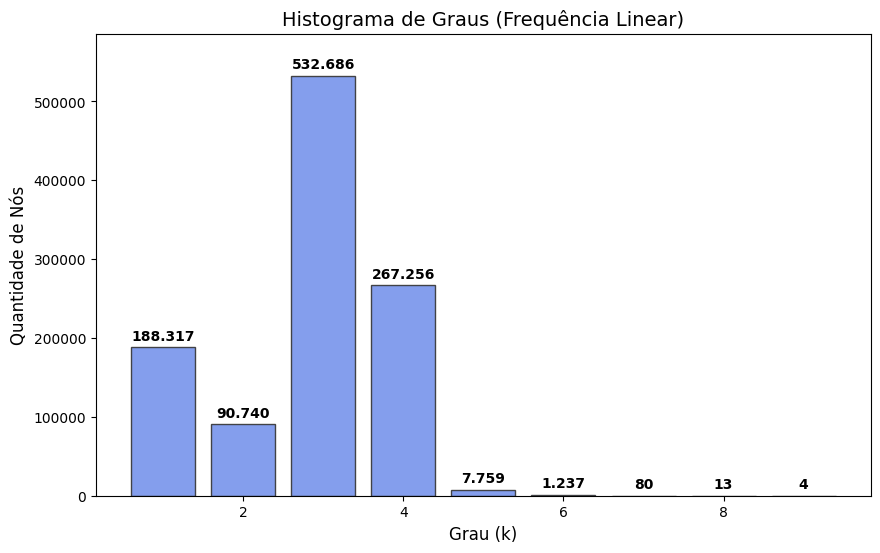

In [3]:
plt.figure(figsize=(10, 6))
bars = plt.bar(df['grau'], df['quantidade'], color='#7794eb', edgecolor='#333333', alpha=0.9)

# Adicionando os números com separador de milhar (Data Labels)
for bar in bars:
    height = bar.get_height()
    if height > 0:
        # A formatação :,.0f coloca a vírgula, e o .replace troca para ponto
        valor_formatado = f'{int(height):,}'.replace(',', '.')

        plt.text(bar.get_x() + bar.get_width()/2., height + 5000,
                 valor_formatado, ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

plt.title("Histograma de Graus (Frequência Linear)", fontsize=14)
plt.xlabel("Grau (k)", fontsize=12)
plt.ylabel("Quantidade de Nós", fontsize=12)

# Ajuste automático do eixo Y para os números não baterem no topo
plt.ylim(0, df['quantidade'].max() * 1.1)

plt.show()

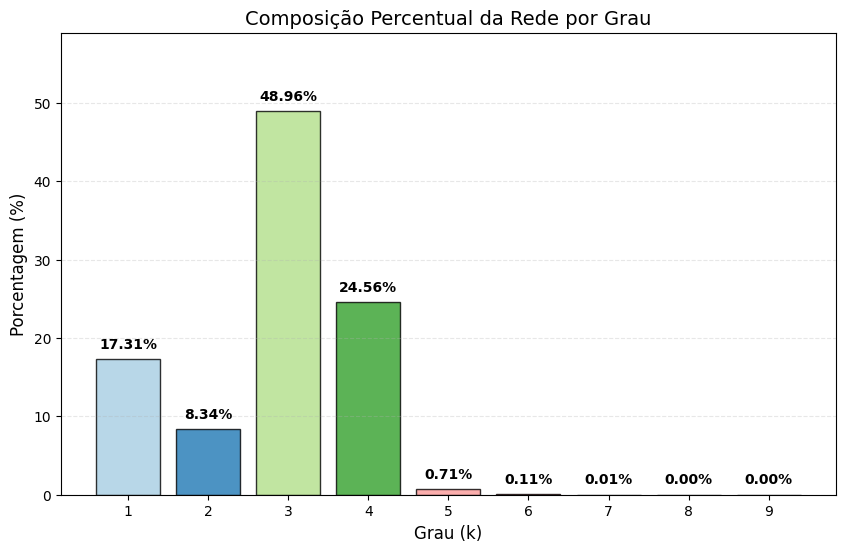


--- Tabela de Frequência Relativa ---
 grau  quantidade  porcentagem
    1      188317    17.307084
    2       90740     8.339368
    3      532686    48.955971
    4      267256    24.561894
    5        7759     0.713083
    6        1237     0.113685
    7          80     0.007352
    8          13     0.001195
    9           4     0.000368


In [4]:
# 1. Calcular as porcentagens
total_nos = df['quantidade'].sum()
df['porcentagem'] = (df['quantidade'] / total_nos) * 100

# 2. Criar o gráfico de barras para porcentagem
plt.figure(figsize=(10, 6))
colors = plt.cm.Paired(range(len(df))) # Cores diferentes para cada grau
bars = plt.bar(df['grau'].astype(str), df['porcentagem'], color=colors, edgecolor='black', alpha=0.8)

# 3. Adicionar o símbolo de % em cima das barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Composição Percentual da Rede por Grau", fontsize=14)
plt.xlabel("Grau (k)", fontsize=12)
plt.ylabel("Porcentagem (%)", fontsize=12)
plt.ylim(0, max(df['porcentagem']) + 10) # Espaço para o texto
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# 4. Tabela de Apoio (opcional)
print("\n--- Tabela de Frequência Relativa ---")
print(df[['grau', 'quantidade', 'porcentagem']].to_string(index=False))

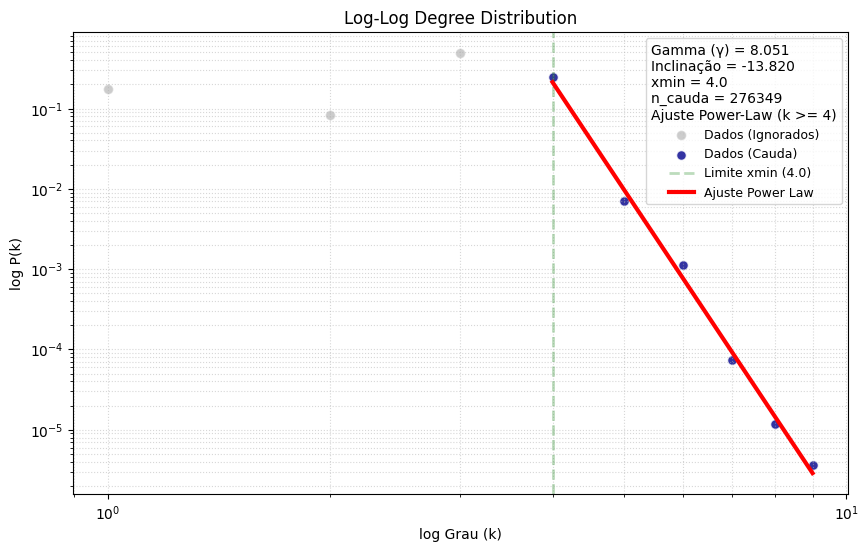

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# URL do arquivo no GitHub
url_dist = 'https://raw.githubusercontent.com/JAlves19/Grafos/refs/heads/main/distribuicao_graus.csv'

try:
    # 1. CARREGAR E PREPARAR DADOS
    df = pd.read_csv(url_dist)
    df = df.sort_values(by=df.columns[0])

    k = df.iloc[:, 0].values.astype(float)
    frequencia = df.iloc[:, 1].values.astype(float)

    # Xmin
    xmin_val = 4.0

    # 2. FILTRAGEM DA CAUDA (k >= xmin)
    mask_cauda = k >= xmin_val
    k_cauda = k[mask_cauda]
    frequencia_cauda = frequencia[mask_cauda]

    # n_cauda é a soma das frequências na cauda
    n_cauda = np.sum(frequencia_cauda)

    # 3. CÁLCULO MANUAL DO GAMMA (Alpha)
    log_sum = np.sum(frequencia_cauda * np.log(k_cauda / (xmin_val - 0.5)))
    gamma_val = 1 + n_cauda * (1 / log_sum)

    # 4. AJUSTE VISUAL (Regressão Linear)
    pk = frequencia / np.sum(frequencia)
    pk_cauda = pk[mask_cauda]

    log_k_vis = np.log10(k_cauda)
    log_pk_vis = np.log10(pk_cauda)

    coef = np.polyfit(log_k_vis, log_pk_vis, 1)
    incl = coef[0]
    inter = coef[1]

    # 5. PLOTAGEM
    plt.figure(figsize=(10, 6))
    plt.style.use("default")

    # Pontos antes do xmin (cinza para destacar que foram ignorados no ajuste)
    plt.scatter(k[~mask_cauda], pk[~mask_cauda], color='gray', edgecolors='white', s=50, alpha=0.4, label="Dados (Ignorados)")

    # Pontos da Cauda (azul escuro)
    plt.scatter(k_cauda, pk_cauda, color='darkblue', edgecolors='white', s=50, alpha=0.8, label="Dados (Cauda)")

    # Linha Recortada Verde (xmin)
    plt.axvline(x=xmin_val, color='forestgreen', linestyle='--', lw=2, alpha= 0.3, label=f"Limite xmin ({xmin_val})")

    # Reta Vermelha
    x_fit = np.linspace(xmin_val, max(k), 100)
    y_fit = 10**(incl * np.log10(x_fit) + inter)
    plt.plot(x_fit, y_fit, color="red", lw=3, label="Ajuste Power Law")

    plt.xscale("log")
    plt.yscale("log")

    # Legenda do gráfico
    texto_stats = (
        f"Gamma (γ) = {gamma_val:.3f}\n"
        f"Inclinação = {incl:.3f}\n"
        f"xmin = {xmin_val}\n"
        f"n_cauda = {int(n_cauda)}\n"
        f"Ajuste Power-Law (k >= 4)"
    )
    plt.legend(title=texto_stats, loc="upper right", frameon=True, fontsize=9)

    plt.title("Log-Log Degree Distribution")
    plt.xlabel("log Grau (k)")
    plt.ylabel("log P(k)")
    plt.grid(True, which="both", ls=":", alpha=0.5)

    plt.show()

except Exception as e:
    print(f"Ocorreu um erro: {e}")

In [6]:
    # Saída no terminal
    print(f"Parâmetros da Lei de Potência (Calculados)")
    print(f"Gamma (Alpha)   : {gamma_val:.5f}")
    print(f"Inclinação (m)  : {incl:.5f}")
    print(f"xmin            : {xmin_val}")
    print(f"Nós na cauda    : {int(n_cauda)}")

Parâmetros da Lei de Potência (Calculados)
Gamma (Alpha)   : 8.05130
Inclinação (m)  : -13.81990
xmin            : 4.0
Nós na cauda    : 276349


In [7]:
print("Métricas Estruturais do Grafo:")
display(metrics_df)

Métricas Estruturais do Grafo:


,Métrica,Valor
0,Vertices,1.088092e+06
1,Arestas,1.541898e+06
2,Densidade,2.604683e-06
3,Grau_Maximo,9.000000e+00
4,Grau_Minimo,1.000000e+00
5,Grau_Medio,2.000000e+00
6,Clustering_Medio,4.521667e-02
